# 2D Grey–Scott Reaction–Diffusion Equation

The Grey–Scott system models two interacting chemical species $u$ and $v$:

$$u_t = \varepsilon_1\,\Delta u + b_1(1 - u) - c_1\,u\,v^2, \quad (x,y) \in (-1,1)^2,\;t \in (0,2)$$
$$v_t = \varepsilon_2\,\Delta v - b_2\,v + c_2\,u\,v^2, \quad (x,y) \in (-1,1)^2,\;t \in (0,2)$$

**Periodic boundary conditions** on both $x$ and $y$.

**Initial conditions:**
$$u_0(x,y) = 1 - e^{-10\left((x+0.05)^2+(y+0.02)^2\right)}$$
$$v_0(x,y) = e^{-10\left((x-0.05)^2+(y-0.02)^2\right)}$$

**Parameters:** $\varepsilon_1=0.2$, $\varepsilon_2=0.1$, $b_1=40$, $b_2=100$, $c_1=c_2=1000$.


In [1]:
import pinns

import numpy as np
import jax.numpy as jnp

## Domain

$(x,y) \in [-1,1]^2$, $t \in [0,2]$. Periodic BCs on both spatial axes.


In [2]:
domain = pinns.DomainCubic(
    space=[(-1.0, 1.0), (-1.0, 1.0)],  # (x_min, x_max), (y_min, y_max)
    time =np.linspace(0.0, 2.0, 11),   # 10 time partitions: [0, 0.2, 0.4, …, 2.0]
)

## PDE Residuals

Two coupled residuals, one per species. The network outputs $[u, v]$.

$$\mathcal{R}_u = u_t - \varepsilon_1(u_{xx} + u_{yy}) - b_1(1-u) + c_1 u v^2 = 0$$
$$\mathcal{R}_v = v_t - \varepsilon_2(v_{xx} + v_{yy}) + b_2 v - c_2 u v^2 = 0$$


In [3]:
import jax

problem = pinns.ProblemStrong(domain=domain, output_names=["u", "v"])

def grey_scott_residual(X, U, params, derivative=None):
    # X columns: 0=x, 1=y, 2=t
    p = params
    eps1 = p['eps1'];  eps2 = p['eps2']
    b1   = p['b1'];    b2   = p['b2']
    c1   = p['c1'];    c2   = p['c2']

    u = U[:, 0:1]
    v = U[:, 1:2]

    dt_all   = derivative.all(X, (2,))       # (N, 2): [u_t,  v_t ]
    dxx_all  = derivative.all(X, (0, 0))     # (N, 2): [u_xx, v_xx]
    dyy_all  = derivative.all(X, (1, 1))     # (N, 2): [u_yy, v_yy]

    u_t  = dt_all[:,  0:1];  v_t  = dt_all[:,  1:2]
    u_xx = dxx_all[:, 0:1];  v_xx = dxx_all[:, 1:2]
    u_yy = dyy_all[:, 0:1];  v_yy = dyy_all[:, 1:2]

    uv2 = u * v**2

    res_u = u_t - eps1 * (u_xx + u_yy) - b1 * (1.0 - u) + c1 * uv2
    res_v = v_t - eps2 * (v_xx + v_yy) + b2 * v          - c2 * uv2

    return jnp.concatenate([res_u, res_v], axis=1)   # (N, 2)

problem.add_inner(grey_scott_residual, name="pde")

def u_initial(X):
    x = X[:, 0:1]
    y = X[:, 1:2]
    u0 = 1.0 - jnp.exp(-10.0 * ((x + 0.05)**2 + (y + 0.02)**2))
    v0 =       jnp.exp(-10.0 * ((x - 0.05)**2 + (y - 0.02)**2))   
    return jnp.concatenate([u0, v0], axis=1)   # (N, 2)

problem.add_initial(u_initial, name="initial", outputs=["u", "v"])

problem.add_parameter("eps1", 0.2)

problem.add_parameter("eps2", 0.1)

problem.add_parameter("b1",   40.0)
problem.add_parameter("b2",   100.0)
problem.add_parameter("c1",   1000.0)
problem.add_parameter("c2",   1000.0)


ProblemStrong(domain=DomainCubic, n_dims=3, n_outputs=2, inner=1, boundary=0, initial=2, params=['eps1', 'eps2', 'b1', 'b2', 'c1', 'c2'], trainable=[])

### Reference Solution (pseudo-spectral ETD2RK)

Both species are evolved spectrally on a 2-D periodic grid using `ModelSpectralSolver` +
`IntegratorETD2RK` (Cox–Matthews exponential time differencing).  In Fourier space:

$$\partial_t \hat{u}_\mathbf{k} = \underbrace{-\varepsilon_1 |\mathbf{k}|^2 \hat{u}_\mathbf{k}}_{\text{linear (exact)}} + \underbrace{\widehat{b_1(1-u) - c_1 u v^2}}_{\text{nonlinear}}$$

`IntegratorETD2RK` treats the stiff diffusion exactly via matrix exponentials
(pointwise in Fourier space), avoiding the small-step restriction of explicit methods.


U_ref shape: (201, 128, 128)  range [0.0003, 1.0000]
V_ref shape: (201, 128, 128)  range [-0.0015, 0.9997]


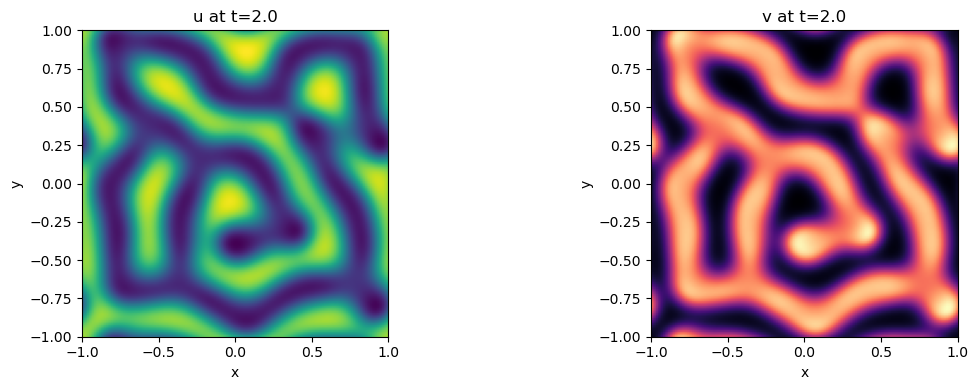

In [ ]:
from scipy.interpolate import RegularGridInterpolator

# ── Parameters ────────────────────────────────────────────────────────────────
eps1_val = 0.2;    eps2_val = 0.1
b1_val   = 40.0;   b2_val   = 100.0
c1_val   = 1000.0; c2_val   = 1000.0

Nx = Ny = 128
Nt = 201        # saved snapshots (includes t=0)
T  = 2.0

t_ref = np.linspace(0.0, T, Nt)

# ── DomainCubic (geometry / sampling) ─────────────────────────────────────────
domain_gs = pinns.DomainCubic(
    space=[(-1.0, 1.0), (-1.0, 1.0)],
    time=(0.0, T),
)

# ── ModelSpectralSolver (2D periodic Fourier basis, shape=(Nx,Ny)) ───────────────────
#   Linear part:  L_u = -eps1*k², L_v = -eps2*k²  (exact in Fourier space)
#   Nonlinear:    N_u = b1*(1-u) - c1*u*v²,  N_v = -b2*v + c2*u*v²

integrator_gs = pinns.IntegratorETD2RK(dt=1e-4, checkpoint=False)

model_gs = pinns.ModelSpectralSolver(domain_gs, ["u", "v"], integrator_gs, shape=(Nx, Ny))

x_ref = np.array(model_gs._grids[0])   # (Nx,)
y_ref = np.array(model_gs._grids[1])   # (Ny,)

# Linear part: L_u = -eps1*k², L_v = -eps2*k²   (X = k, wavenumbers magnitude)
model_gs.set_linear_op(
    lambda X, p: {
        "u": -p["eps1"] * X**2,
        "v": -p["eps2"] * X**2,
    }
)

# Nonlinear part   (X = k, U = state dict in spectral space)
def gs_nonlinear(X, U, p):
    u   = model_gs.inverse(U["u"])
    v   = model_gs.inverse(U["v"])
    uv2 = u * v**2
    Nu  = p["b1"] * (1.0 - u) - p["c1"] * uv2
    Nv  = -p["b2"] * v        + p["c2"] * uv2
    return {
        "u": model_gs.forward(Nu),
        "v": model_gs.forward(Nv),
    }

model_gs.set_nonlinear_op(gs_nonlinear)
model_gs.add_parameter("eps1", eps1_val)
model_gs.add_parameter("eps2", eps2_val)
model_gs.add_parameter("b1",   b1_val)
model_gs.add_parameter("b2",   b2_val)
model_gs.add_parameter("c1",   c1_val)
model_gs.add_parameter("c2",   c2_val)

# ── Initial conditions ────────────────────────────────────────────────────────
XX, YY = np.meshgrid(x_ref, y_ref, indexing='ij')
u0 = jnp.array(1.0 - np.exp(-10.0 * ((XX + 0.05)**2 + (YY + 0.02)**2)))
v0 = jnp.array(      np.exp(-10.0 * ((XX - 0.05)**2 + (YY - 0.02)**2)))

model_gs.add_initial({"u": u0, "v": v0})

# ── Forward solve ─────────────────────────────────────────────────────────────
sol = model_gs.solve(t_obs=t_ref)
U_ref = np.array(sol["u"])   # (Nt, Nx, Ny)
V_ref = np.array(sol["v"])   # (Nt, Nx, Ny)

print(f"U_ref shape: {U_ref.shape}  range [{U_ref.min():.4f}, {U_ref.max():.4f}]")
print(f"V_ref shape: {V_ref.shape}  range [{V_ref.min():.4f}, {V_ref.max():.4f}]")

# ── Interpolants: X[:,0]=x, X[:,1]=y, X[:,2]=t → (N,2) ──────────────────────
_interp_u = RegularGridInterpolator(
    (x_ref, y_ref, t_ref),
    U_ref.transpose(1, 2, 0),   # (Nx, Ny, Nt)
    method='linear', bounds_error=False, fill_value=None,
)
_interp_v = RegularGridInterpolator(
    (x_ref, y_ref, t_ref),
    V_ref.transpose(1, 2, 0),
    method='linear', bounds_error=False, fill_value=None,
)

def uv_reference(X):
    """X[:,0]=x, X[:,1]=y, X[:,2]=t → (N,2)"""
    pts = np.asarray(X)[:, :3]
    return np.concatenate([
        _interp_u(pts)[:, None],
        _interp_v(pts)[:, None],
    ], axis=1)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(U_ref[-1], extent=(-1,1,-1,1), origin='lower', cmap='viridis')
axes[0].set_title(f"u at t={T}"); axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[1].imshow(V_ref[-1], extent=(-1,1,-1,1), origin='lower', cmap='magma')
axes[1].set_title(f"v at t={T}"); axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.tight_layout()


# Inverse Problem: Recovering all 6 Grey–Scott Parameters

We treat all six parameters as unknown and recover them simultaneously.

## Scale issue

The parameters span four orders of magnitude ($\varepsilon \sim 10^{-1}$, $b \sim 10^1$–$10^2$, $c \sim 10^3$).
With a shared learning rate, Adam gradients for small parameters are swamped by large ones.

**Solution — log-reparameterisation**: optimise $\ell_\theta = \log\theta$ instead of $\theta$.
Each operator then reads `jnp.exp(p["log_eps1"])` etc.  Because the gradient of the loss w.r.t.
$\ell_\theta$ is $\theta \cdot \partial \mathcal{L}/\partial\theta$, a unit step in log-space
equals a *multiplicative* change — fully scale-invariant regardless of magnitude.

$$\min_{\ell_{\varepsilon_1},\ell_{\varepsilon_2},\ell_{b_1},\ell_{b_2},\ell_{c_1},\ell_{c_2}} \;
\frac{1}{N}\sum_i \Bigl(\bigl|u^{\text{pred}}_i - u^{\text{obs}}_i\bigr|^2
                       +\bigl|v^{\text{pred}}_i - v^{\text{obs}}_i\bigr|^2\Bigr)$$

| Parameter | True $\theta$ | Log initial guess |
|-----------|--------------|-------------------|
| $\varepsilon_1$ | 0.20 | $\log 0.14 \approx -1.97$ |
| $\varepsilon_2$ | 0.10 | $\log 0.07 \approx -2.66$ |
| $b_1$ | 40.0 | $\log 28 \approx 3.33$ |
| $b_2$ | 100.0 | $\log 70 \approx 4.25$ |
| $c_1$ | 1000.0 | $\log 700 \approx 6.55$ |
| $c_2$ | 1000.0 | $\log 700 \approx 6.55$ |

All log-parameters are now $\mathcal{O}(1)$–$\mathcal{O}(10)$ — a single learning rate works well.


In [ ]:
# ── Noisy observations (1% Gaussian noise on both u and v) ───────────────────
rng_np  = np.random.default_rng(42)
U_noisy = U_ref + rng_np.normal(0, 0.01, U_ref.shape)
V_noisy = V_ref + rng_np.normal(0, 0.01, V_ref.shape)

# ── Inverse ModelSpectralSolver — log-reparameterised ─────────────────────────────────
# We optimise log(θ) instead of θ.  The operators call jnp.exp(p["log_*"]) to
# recover the physical parameter.  This makes all optimised variables O(1-10)
# regardless of the original magnitude, so a single learning rate works for all.

integrator_inv = pinns.IntegratorETD2RK(dt=1e-4, checkpoint=True)
model_inv = pinns.ModelSpectralSolver(domain_gs, ["u", "v"], integrator_inv, shape=(Nx, Ny))

# Linear part: L_u = -exp(log_eps1)*k², L_v = -exp(log_eps2)*k²  (X = k)
model_inv.set_linear_op(
    lambda X, p: {
        "u": -jnp.exp(p["log_eps1"]) * X**2,
        "v": -jnp.exp(p["log_eps2"]) * X**2,
    }
)

# Nonlinear part   (X = k, U = state dict in spectral space)
def gs_nonlinear_inv(X, U, p):
    u   = model_inv.inverse(U["u"])
    v   = model_inv.inverse(U["v"])
    uv2 = u * v**2
    b1  = jnp.exp(p["log_b1"]);  b2  = jnp.exp(p["log_b2"])
    c1  = jnp.exp(p["log_c1"]);  c2  = jnp.exp(p["log_c2"])
    return {
        "u": model_inv.forward(b1 * (1.0 - u) - c1 * uv2),
        "v": model_inv.forward(-b2 * v        + c2 * uv2),
    }

model_inv.set_nonlinear_op(gs_nonlinear_inv)

# Register log-parameters with perturbed initial guesses (~30% off true values)
model_inv.add_parameter("log_eps1", float(np.log(0.14)))   # true: log(0.20)
model_inv.add_parameter("log_eps2", float(np.log(0.07)))   # true: log(0.10)
model_inv.add_parameter("log_b1",   float(np.log(28.0)))   # true: log(40.0)
model_inv.add_parameter("log_b2",   float(np.log(70.0)))   # true: log(100.0)
model_inv.add_parameter("log_c1",   float(np.log(700.0)))  # true: log(1000.0)
model_inv.add_parameter("log_c2",   float(np.log(1000.0)))  # true: log(1000.0)

model_inv.add_initial({"u": u0, "v": v0})

# Observation times must be registered for interpolation inside the solve loop
model_inv._obs_times = t_ref


Starting training for 500 epochs (JIT-compiled)...


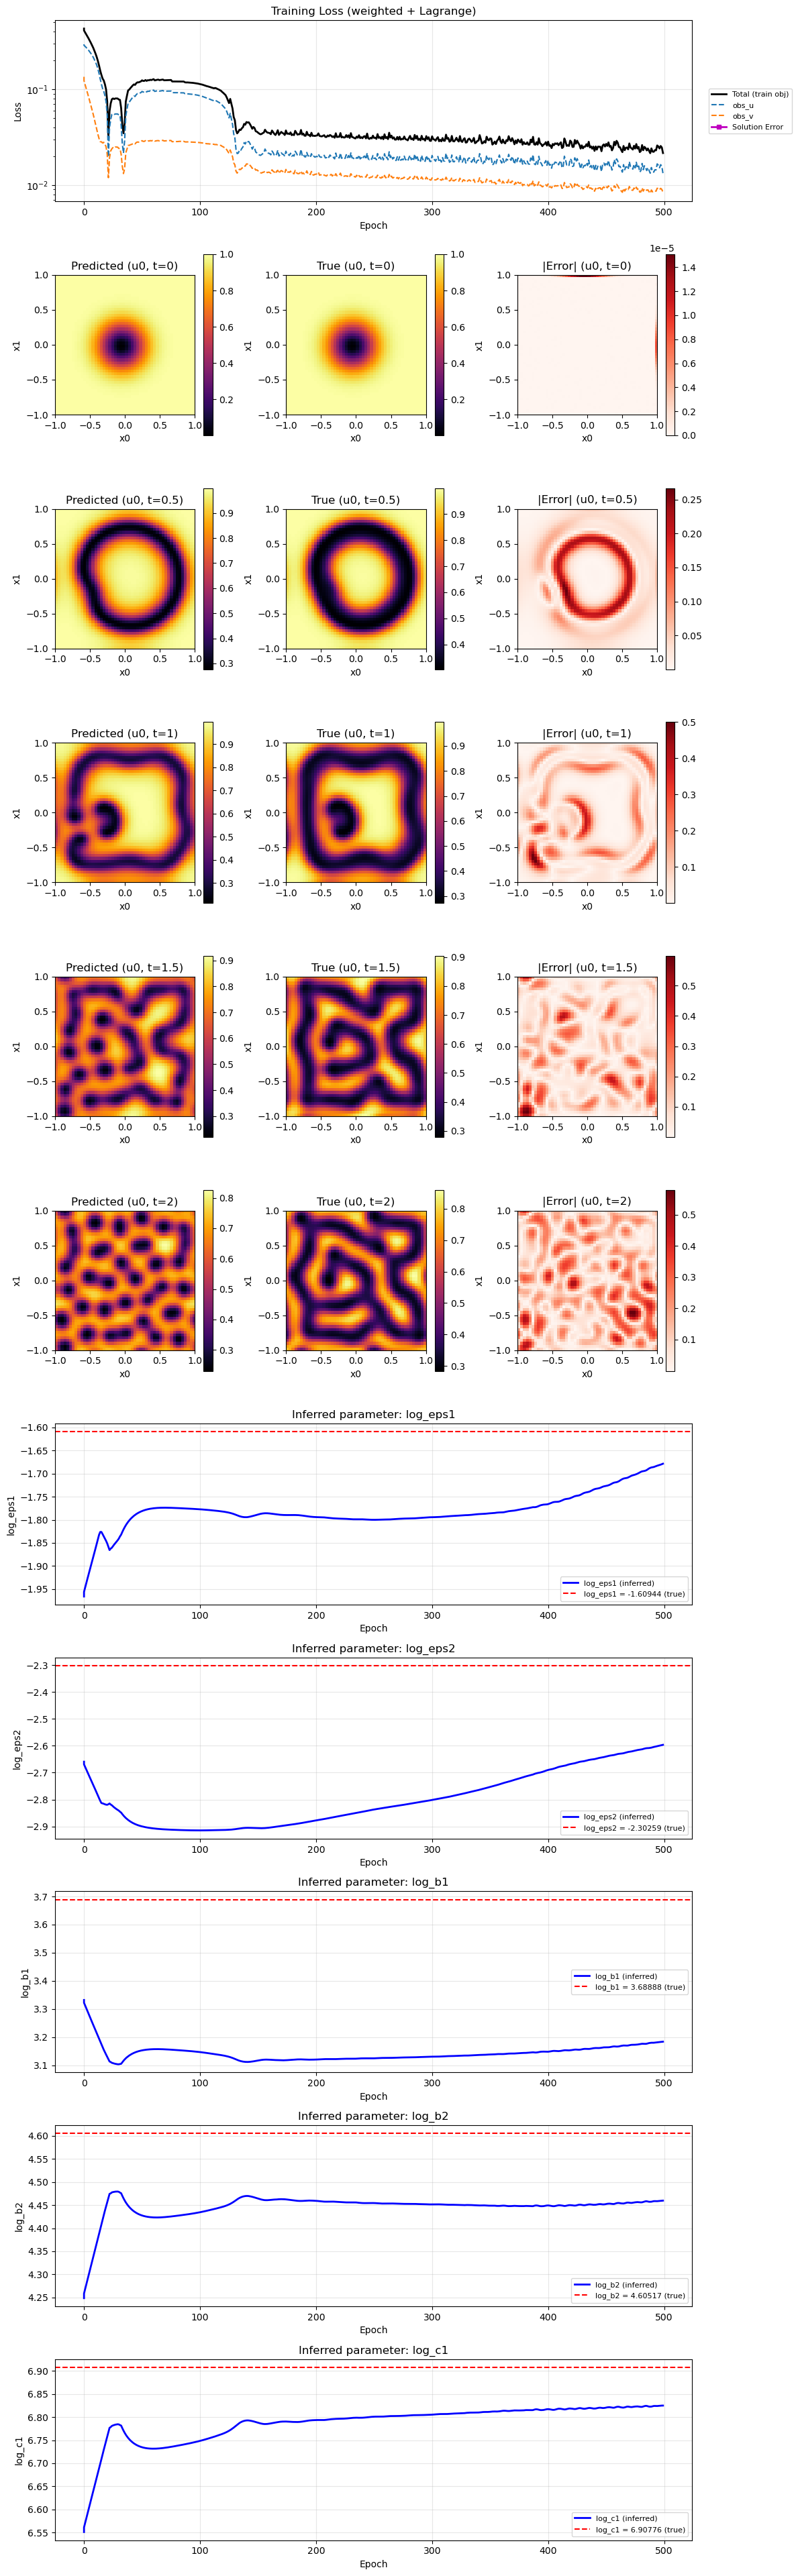

Epoch 0/500 | Loss: 4.29e-01 | MSE: 4.29e-01 | Terms: [] | Data: [obs_u: 2.94e-01, obs_v: 1.35e-01] | Error: N/A | Params: [log_eps1: -1.96611, log_eps2: -2.65926, log_b1: 3.3322, log_b2: 4.2485, log_c1: 6.55108] | Time: 0.0s
Epoch 1/500 | Loss: 4.10e-01 | MSE: 4.10e-01 | Terms: [] | Data: [obs_u: 2.87e-01, obs_v: 1.22e-01] | Error: N/A | Params: [log_eps1: -1.95611, log_eps2: -2.66926, log_b1: 3.3222, log_b2: 4.2585, log_c1: 6.56108] | Time: 114.3s
Epoch 2/500 | Loss: 3.91e-01 | MSE: 3.91e-01 | Terms: [] | Data: [obs_u: 2.79e-01, obs_v: 1.11e-01] | Error: N/A | Params: [log_eps1: -1.94629, log_eps2: -2.6791, log_b1: 3.31222, log_b2: 4.26849, log_c1: 6.57106] | Time: 228.3s
Epoch 3/500 | Loss: 3.72e-01 | MSE: 3.72e-01 | Terms: [] | Data: [obs_u: 2.71e-01, obs_v: 1.01e-01] | Error: N/A | Params: [log_eps1: -1.93662, log_eps2: -2.6888, log_b1: 3.30225, log_b2: 4.27847, log_c1: 6.58102] | Time: 336.4s
Epoch 4/500 | Loss: 3.54e-01 | MSE: 3.54e-01 | Terms: [] | Data: [obs_u: 2.63e-01, obs_v

AttributeError: 'Trainer' object has no attribute 'get_model_parameters'

In [6]:
# ── Dataset: scattered (x, y, t) observations of both u and v ────────────────
XX_grid, YY_grid, TT_grid = np.meshgrid(x_ref, y_ref, t_ref, indexing='ij')

X_obs = np.stack([
    XX_grid.ravel(),
    YY_grid.ravel(),
    TT_grid.ravel(),
], axis=-1).astype(np.float32)

U_obs_flat = U_noisy.transpose(1, 2, 0).ravel().astype(np.float32)
V_obs_flat = V_noisy.transpose(1, 2, 0).ravel().astype(np.float32)

n_obs = 8192
idx   = rng_np.choice(len(X_obs), size=n_obs, replace=False)

dataset = pinns.Dataset()
dataset.add_points(X_obs[idx], U_obs_flat[idx], name="obs_u", component=0)
dataset.add_points(X_obs[idx], V_obs_flat[idx], name="obs_v", component=1)

# ── Reference interpolants ────────────────────────────────────────────────────
def uv_reference_inv(X):
    pts = np.asarray(X)[:, :3]
    return np.concatenate([
        _interp_u(pts)[:, None],
        _interp_v(pts)[:, None],
    ], axis=1)

# ── Trainer ───────────────────────────────────────────────────────────────────
trainer_inv = pinns.Trainer(model_inv, dataset=dataset)
trainer_inv.set_solution(uv_reference_inv)

# True log-values as reference lines in the convergence plot
for name, true_val in [
    ("log_eps1", np.log(0.20)), ("log_eps2", np.log(0.10)),
    ("log_b1",   np.log(40.0)), ("log_b2",   np.log(100.0)),
    ("log_c1",   np.log(1000.0)), ("log_c2", np.log(1000.0)),
]:
    trainer_inv.set_solution_parameter(name, float(true_val))

trainer_inv.compile(
    fit_model_parameters=["log_eps1", "log_eps2", "log_b1", "log_b2", "log_c1"],
    optimizer=pinns.AdamOptimizer(learning_rate=1e-2),
    epochs=500,
    print_each=1,
    show=pinns.TrainPlotter(
        time_points=[0.0, 0.5, 1.0, 1.5, 2.0]
    )
)

trainer_inv.train()

# ── Recover physical parameters after training ────────────────────────────────
p_trained = trainer_inv.get_model_parameters()
print("\nRecovered parameters:")
for log_name, true_val in [
    ("log_eps1", 0.20), ("log_eps2", 0.10),
    ("log_b1",   40.0), ("log_b2",  100.0),
    ("log_c1", 1000.0), ("log_c2", 1000.0),
]:
    name = log_name[4:]   # strip "log_"
    recovered = float(np.exp(p_trained[log_name]))
    print(f"  {name:5s}: true={true_val:8.3f}  recovered={recovered:8.3f}  "
          f"rel_err={abs(recovered - true_val)/true_val*100:.1f}%")